# 08_优化算法-RMSProp

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天聊聊优化算法中的RMSProp\~

RMSProp（Root Mean Square Propagation）是一种常用于训练神经网络的优化算法，主要目的是让模型的学习过程更加高效和稳定。

**首先，为什么需要优化算法？**

在训练模型时，我们不断调整模型中的参数（也就是“权重”），使得模型预测的结果与真实数据之间的差距（通常用损失函数来表示）越来越小。常用的调整方式是梯度下降法，它根据每个参数的梯度来决定每次调整的方向和幅度。

但梯度下降法有时会遇到两个问题：

- **梯度震荡**：当不同参数的梯度变化很大时，有些参数更新太快而有些太慢。
- **学习率设置难题**：如果学习率太大，模型可能在最优值周围“跳来跳去”；如果太小，收敛速度又会非常慢。

**那么，RMSProp的基本思路是什么？**

RMSProp 针对传统梯度下降方法中的问题提出了解决方案，其主要思路是对不同参数采用不同的“自适应学习率”，也就是说让算法根据历史梯度信息自动调整每个参数的更新步长。

#### 核心机制

- **记录梯度的平方平均值**：对于每一个参数，RMSProp会维护一个“移动平均值”，专门用来记录近期梯度的平方值。可以理解为“它看这些梯度过去表现如何（大还是小）”。
- **自适应调整学习率**：当一个参数的梯度长期较大时，RMSProp会降低这个参数的学习率；而当梯度较小时，就保持或者略微提高学习率。这样可以避免部分参数因梯度太大而更新过快，也能使得梯度较小的参数得到足够的更新。

理解起来其实很简单，当你在山上找最低点，每次你得靠感觉下山的方向和步长。如果你一路上的下坡路非常陡峭，那么每步应该走得小一些，防止踩空；而如果路比较平缓，就可以走得快一点。

RMSProp 就好比一个聪明的同行者，它会根据你之前走过的路的“坡度强度”来告诉你“现在别走太快”或者“可以大胆一些”。这样一来，无论山路多么崎岖，你都能更稳妥地走到山谷（也就是最低点）。

**RMSProp的优点**：

- **自适应调整**：不需要人工为每个参数设定不同的学习率，自动适应各自的梯度波动。
- **减少震荡**：有效平滑因梯度过大引起的参数更新，帮助训练过程更稳定。
- **实践中效果好**：在许多实际的神经网络训练场景中，RMSProp表现出收敛快和鲁棒性较好的优势。

总结起来，RMSProp 是一种通过记录并利用梯度平方的历史信息，自动调整每个参数学习率的算法。这种自适应机制能够帮助我们在各种复杂情况下降低训练中的不稳定因素，加快模型达到最优解的速度。大家可以将其理解为“根据过去的路况调整步伐”，从而使得整个训练过程更稳健、更高效。

## 原理详解

在机器学习中，为了使损失函数 $J(\theta)$最小化，我们通常采用梯度下降法进行参数更新。标准的梯度下降更新公式为


$$
\theta_{t+1} = \theta_t - \eta \, g_t,
$$


其中

- $\theta_t$ 是在第 $t$ 次迭代时的模型参数，
- $\eta$ 是学习率，
- $g_t = \nabla_\theta J(\theta_t)$ 是损失函数关于参数的梯度。

然而，标准梯度下降法存在两个主要问题：

1. **学习率难以选择**：固定的学习率 $\eta$ 对所有参数统一使用，可能对局部平坦区域和陡峭区域都不适合。
2. **梯度尺度不均问题**：不同参数的梯度幅度可能相差较大，导致部分参数更新过快或更新不足。

为了解决这些问题，RMSProp 通过自适应地调整每个参数的学习率，使得参数更新更加平稳和高效。

### RMSProp 数学原理

#### 梯度平方的滑动平均

RMSProp 的主要创新在于为每个参数维护一个梯度平方的“滑动平均值”。记住，每次迭代时，不仅使用当前梯度，还考虑历史梯度的平方大小。

令：$E[g^2]_t$ 表示到第 $t$ 次迭代为止，当前参数梯度平方的指数加权移动平均。具体更新公式为


$$
E[g^2]_t = \gamma \, E[g^2]_{t-1} + (1 - \gamma) \, g_t^2,
$$


其中

- $\gamma \in [0,1)$ 是衰减因子（常见取值如 0.9 或 0.99），用于控制历史梯度影响的衰减速度，
- $g_t^2$ 表示梯度的平方。对于向量 $\theta$，这个操作是在每个维度上独立进行的。

这种指数加权移动平均可以看作是一种“记忆”，让算法对过去一段时间内梯度的幅度有统计信息。它能平滑随机梯度的高频震荡，也为后续自适应学习率提供依据。

#### 自适应学习率：标准化梯度

由于梯度幅度较大的参数可能导致更新步长过大，RMSProp 通过对梯度进行归一化来达到平衡。具体来说，使用“均方根”（Root Mean Square，简称 RMS）来调整更新步长。

归一化后的梯度更新公式为：


$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}}\, g_t,
$$


其中

- $\eta$ 是基础学习率，
- $\sqrt{E[g^2]_t + \epsilon}$ 则代表当前梯度的均方根（为了防止除以 0，加上非常小的常数 $\epsilon$ ，通常取 $10^{-8}$ 或类似数值）。

帮助理解：

- 当历史上的梯度平方较大时，$\sqrt{E[g^2]_t}$ 较大，从而使得 $\frac{\eta}{\sqrt{E[g^2]_t + \epsilon}}$较小，这就降低了当前参数更新的步长。
- 当梯度较小，历史平方平均较小，步长就相对较大，有助于加速收敛。

这种做法使得每个参数都能根据自身过去的梯度信息“自适应”调整学习率，避免因为梯度值大而导致的发散问题，同时也能在梯度较小时加快更新速度。

### 算法流程及公式推导

下面按步骤细化 RMSProp 算法的数学流程和公式推导：

##### 步骤 1：初始化

- 初始化模型参数 $\theta_0$（可以随机初始化）。
- 初始化梯度平方的滑动平均 $E[g^2]_0$（通常设为 0 或一个很小的正数）。

##### 步骤 2：梯度计算

在第 $t$ 次迭代中，根据当前参数 $\theta_t$ 计算损失函数的梯度


$$
g_t = \nabla_\theta J(\theta_t).
$$


这里 $g_t$ 可以是一个标量（针对单参数）或一个向量（针对多个参数）。

##### 步骤 3：更新梯度平方的滑动平均

计算当前梯度平方更新后的滑动平均 $E[g^2]_t$，


$$
E[g^2]_t = \gamma \, E[g^2]_{t-1} + (1 - \gamma) \, g_t^2.
$$


这个公式利用了指数加权的思想，衰减因子 $\gamma$ 决定了前面所有梯度对当前平均值的影响权重。

##### 步骤 4：参数更新

利用归一化后的梯度对参数进行更新，公式为


$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}}\, g_t.
$$


这里的关键在于：

- 学习率被自适应地缩放到 $\frac{\eta}{\sqrt{E[g^2]_t + \epsilon}}$；
- 保证了梯度较大的参数更新时步长受到抑制，从而减小参数更新时可能出现的震荡。

##### 数学直观理解

可以将 RMSProp 公式看作对标准梯度更新的一种归一化处理。

常见的思路如下：

1. **平滑作用**：通过 $E[g^2]_t$ 实现对梯度波动的平滑，类似信号处理中的“低通滤波器”。
2. **归一化**：与其直接用 $g_t$ 进行更新，不如用比例因子 $1/\sqrt{E[g^2]_t+\epsilon}$ 对梯度进行规范化，从而在梯度方向上保证每一步都有合理的步长。
3. **动态调整步长**：这种归一化实际上给每个参数赋予了一个自适应的学习率，与时间一起不断变化，而不需要人为设置复杂的学习率调整策略。

总结起来，就3步：

1. **记录梯度变化信息**：通过指数加权平均 $E[g^2]_t = \gamma E[g^2]_{t-1} + (1 - \gamma) g_t^2$，捕获近期梯度的“能量”或“波动”；
2. **自适应调整学习率**：用归一化因子 $\frac{1}{\sqrt{E[g^2]_t+\epsilon}}$ 对梯度进行缩放，使得梯度大的方向采取较小的步长；
3. **更新参数**：最终使用更新公式 $\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t+\epsilon}} g_t$ 实现高效而稳定的参数调整。

这种机制既避免了在陡峭区域步长过大导致的不稳定，又能在平缓区域保持适当的步长以加速收敛，是一种非常实用的自适应学习率优化方法。

## 完整案例

下面的代码中，我们手动实现了 RMSProp 算法，包括梯度的计算、累积平方梯度的更新以及参数的更新步骤。

我们还将整个迭代过程中参数的轨迹记录下来，并利用 matplotlib 绘制轮廓图和损失曲线\~

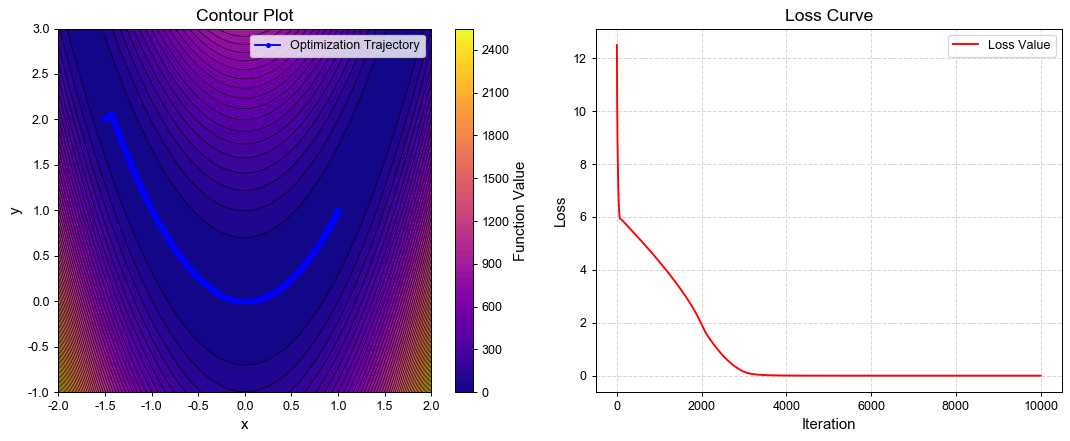

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 定义 Rosenbrock 函数及其梯度
def rosenbrock(x, y):
    """
    计算 Rosenbrock 函数的值
    f(x, y) = (1-x)^2 + 100*(y - x^2)^2
    """
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    """
    计算 Rosenbrock 函数关于 x 和 y 的梯度
    对 x 的偏导数： df/dx = -2*(1-x) - 400*x*(y-x^2)
    对 y 的偏导数： df/dy = 200*(y-x^2)
    """
    dx = -2*(1 - x) - 400*x*(y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# 实现 RMSProp 算法
def rmsprop_optimize(grad_func, init_params, lr=0.001, decay_rate=0.9, epsilon=1e-8, max_iter=10000, tol=1e-8):
    """
    使用 RMSProp 算法优化目标函数参数

    参数：
        grad_func: 函数句柄，返回目标函数在当前点的梯度
        init_params: 初始参数（numpy 数组），例如 np.array([x0, y0])
        lr: 学习率（基本步长）
        decay_rate: 衰减因子，用于累积平方梯度 (通常取值 0.9~0.99)
        epsilon: 防止除 0 的微小常量
        max_iter: 最大迭代次数
        tol: 当梯度模长小于 tol 时，停止迭代

    返回：
        params_history: 参数更新的轨迹
        loss_history: 每次迭代的损失函数值
    """
    params = init_params.copy()  # 当前参数
    grad_squared_avg = np.zeros_like(params)  # 累积平方梯度初始化为 0
    params_history = [params.copy()]  # 记录参数轨迹
    loss_history = [rosenbrock(params[0], params[1])]  # 记录损失历史

    # 开始迭代优化过程
    for iter in range(max_iter):
        grad = grad_func(params[0], params[1])
        
        # RMSProp 算法核心：累积平方梯度的指数衰减平均
        grad_squared_avg = decay_rate * grad_squared_avg + (1 - decay_rate) * grad**2
        
        # 参数更新：通过除以平方根的累积梯度，调节学习率
        params -= lr * grad / (np.sqrt(grad_squared_avg) + epsilon)
        
        # 记录当前参数及损失值
        params_history.append(params.copy())
        current_loss = rosenbrock(params[0], params[1])
        loss_history.append(current_loss)
        
        # 判断是否满足收敛条件：梯度模长小于 tol 则停止迭代
        if np.linalg.norm(grad) < tol:
            print(f"Convergence reached at iteration {iter}")
            break

    return np.array(params_history), np.array(loss_history)

# 主函数
if __name__ == '__main__':
    # 初始化起始参数，选择一个远离全局最优解的起点
    init_params = np.array([-1.5, 2.0])
    
    # 调用 RMSProp 算法，设置合理的学习率和衰减因子
    params_history, loss_history = rmsprop_optimize(rosenbrock_grad, init_params, lr=0.001, decay_rate=0.9, max_iter=10000)
    
    # 提取 x 和 y 坐标的变化轨迹
    x_vals = params_history[:, 0]
    y_vals = params_history[:, 1]
    
    # 可视化：绘制 Rosenbrock 函数轮廓图与优化轨迹
    # 设置网格用于绘制等高线
    x_grid = np.linspace(-2, 2, 400)
    y_grid = np.linspace(-1, 3, 400)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = rosenbrock(X, Y)

    plt.figure(figsize=(12, 5))

    # 绘制第一个子图：Contour Plot
    plt.subplot(1, 2, 1)
    contour = plt.contourf(X, Y, Z, levels=50, cmap='plasma')
    # 绘制等高线并添加颜色条
    plt.contour(X, Y, Z, levels=50, colors='k', linewidths=0.5)
    plt.plot(x_vals, y_vals, 'bo-', markersize=3, label="Optimization Trajectory")
    plt.title("Contour Plot", fontsize=14)
    plt.xlabel("x", fontsize=12)
    plt.ylabel("y", fontsize=12)
    plt.legend()
    cbar = plt.colorbar(contour)
    cbar.ax.set_ylabel("Function Value", fontsize=12)
   
    # 可视化：绘制损失函数下降曲线
    plt.subplot(1, 2, 2)
    plt.plot(loss_history, 'r-', label="Loss Value")
    plt.title("Loss Curve", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

我们实现了 Rosenbrock 函数和其梯度函数，这两部分构成了优化问题的基础。

- `rosenbrock(x, y)` 用于计算函数值。
- `rosenbrock_grad(x, y)` 返回目标函数在当前点的梯度，便于 RMSProp 算法在每一步更新参数。

**RMSProp 核心算法**

在 `rmsprop_optimize` 函数中，我们依照 RMSProp 的算法逻辑：

- 首先对梯度平方进行指数衰减平均，存储在 `grad_squared_avg` 中；
- 然后利用更新公式对参数进行迭代更新。
- 同时，通过收敛条件（梯度模长小于预设阈值 tol）判断是否提前结束迭代，这能够加速收敛。

![原文参考图，当前结果见代码输出](attachments/img_025.png)

- 第一幅图为目标函数的等高线图，并叠加了 RMSProp 算法的优化轨迹，展现出参数更新路径；
- 第二幅图绘制了损失函数下降趋势图，直观反映出参数迭代过程中目标函数值逐渐减小的情况。

注释部分从目标函数、算法原理、参数设置、可视化解读、图像风格、总结及未来拓展等多个角度进行了详细解读，帮助读者理解 RMSProp 算法在实际问题中的应用及优势。

通过这一完整示例，我们不仅展示了如何在实际问题中使用 RMSProp 算法，而且为读者提供了深入的分析和直观的图形展示，希望能帮助大家更好地理解和掌握该优化算法在工程实践中的应用。

## 模型分析

### RMSProp 优缺点

**优点：**

1. **自适应学习率**：RMSProp 能够根据参数维度上的历史梯度平方自动调整学习率，使得每个参数拥有独立的、动态变化的更新步长。这种机制尤其适用于目标函数在不同方向上具有不同梯度尺度的问题（如 Rosenbrock 函数）。
2. **高效处理非凸问题**：相较于传统 SGD，RMSProp 在面对复杂、非线性、非凸的目标函数（如带有“沟谷结构”的 Rosenbrock 函数）时，表现出更强的稳定性和收敛速度。
3. **避免震荡与梯度爆炸问题**：累积平方梯度的平滑处理使得 RMSProp 在陡峭或震荡区域不会出现大幅跳跃，尤其在高梯度区域能够自动减小步长，保持训练稳定。
4. **低内存开销**：RMSProp 只需保存每个参数的一个额外累积量（梯度平方的指数平均值），内存开销远小于 AdaGrad、Adam 等算法的多累积变量设计。

**缺点：**

1. **不具备动量项**：RMSProp 不像 Adam 那样结合了动量机制，因此在平坦区域收敛速度可能略慢，或者容易陷入局部最优而非持续向前推进。
2. **敏感的超参数**：学习率（lr）、衰减因子（decay_rate）等超参数的选择对优化性能影响较大。在实际问题中需通过经验或调参策略找到合适的组合。
3. **不适合过强震荡/稀疏梯度问题**：尽管 RMSProp 在一定程度上缓解了梯度震荡问题，但对于梯度过于稀疏或具有严重震荡问题的情况，Adam 或 AdaGrad 可能更优。

### RMSProp 与其他相似优化算法对比

| 算法名称 | 是否自适应学习率 | 是否使用动量 | 特点 | 优缺点概括 |
|-|-|-|-|-|
| **SGD** | ❌ | ❌ | 最基础的优化算法，更新简单 | 优点：实现简单，广泛适用；  <br/>缺点：收敛慢，需精调学习率 |
| **Momentum** | ❌ | ✅ | 加入前一轮梯度的“惯性”，提升收敛速度 | 优点：加快收敛，减少震荡；  <br/>缺点：仍需手动设定全局学习率 |
| **AdaGrad** | ✅ | ❌ | 每个参数具有独立的学习率（累积平方梯度），对稀疏数据表现良好 | 优点：适用于稀疏梯度问题；  <br/>缺点：学习率单调下降，最终可能变得太小 |
| **RMSProp** | ✅ | ❌ | 改进 AdaGrad，采用指数平均防止学习率消失 | 优点：收敛快，适应性好；  <br/>缺点：对超参数敏感，缺动量机制 |
| **Adam** | ✅ | ✅ | 结合 Momentum 与 RMSProp 的优点，适用于大多数深度学习任务 | 优点：收敛速度快，鲁棒性强；  <br/>缺点：理论收敛性略逊于 SGD |

### 什么时候 RMSProp 是优选？何时应考虑其他算法？

**RMSProp 是优选的场景：**

- **非凸优化问题，目标函数变化剧烈**：如 Rosenbrock 函数、RNN 等梯度不稳定场景，RMSProp 能稳定收敛；
- **计算资源有限，追求收敛速度**：不希望每次手动调节学习率，RMSProp 提供良好的自动调整机制；
- **轻量级机器学习模型或在线学习**：其内存需求远小于 Adam，更适合边训练边更新的小型模型或在线模型。

**应考虑其他算法的情况：**

- **梯度非常稀疏（如 NLP 中词向量训练）** → 推荐 **AdaGrad**；
- **需要快速收敛 + 全面鲁棒性** → 推荐 **Adam**（尤其在深度学习任务中非常流行）；
- **对最终精度要求极高，且训练过程长** → 推荐 **SGD with Momentum**，尽管慢但可精细控制；
- **问题结构简单、已知学习率最佳范围** → 使用 **SGD** 可获得理论最优收敛。

总的来说，RMSProp 是一种在高非线性、高曲率函数下表现优秀的优化算法，其自适应机制非常适合复杂模型的快速调优，但在追求极致稳定性和精度的场合，可以考虑采用带动量或更稳定变种的优化算法，如 Adam 或 SGD with Momentum。